<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Математический анализ 2

**Ключевые слова**: производная, геометрический смысл производной, интеграл, геометрический смысла интеграла

**Программа лекции**:
1. Что такое производная?
2. Производная и касательная к кривой
3. Определение интеграла
4. Площадь под графиком функции и интеграла
5. Градиентный спуск

# Производная функции одной переменной

1. **Производная как мера крутизны**:
   Производная функции в точке $ x = 2 $ равна $ f'(2) = 4 $, что количественно определяет крутизну функции в этой точке.

2. **Наклон функции**:
   В точке $ x = 2 $ наклон функции $ f(x) = x^2 $ равен 4, указывая на быстрое увеличение значения функции.

3. **Физическая интерпретация**:
   Крутизна склона функции при $ x = 2 $ значительна (равна 4), что означает резкое ускорение вниз при движении по "горке".

<details>
  <summary>Текст</summary>

  **Производная** отражает темп изменений функции в данной точке и находит широкое применение в машинном обучении, особенно в контексте алгоритма градиентного спуска. Отсутствие наклона (нулевая производная) свидетельствует о возможной точке минимума или максимума целевой переменной. С производной вы столкнётесь, изучая линейную и логистическую регрессию, а также при знакомстве с нейронными сетями, да и вообще один из базовых алгоритмов в машинном обучении метод наискорейшего спуска "работает на производных".


  Давайте исследуем конкретный пример. Проанализируем функцию $f(x) = x^2$ на *Рисунке 1*. Давайте подумаем про крутизну этой функции, как если бы поверхность её была горой покрытой снегом, а мы хотели бы скатиться по ней, например, на лыжах. Если бы мы оказались в точке $x = 0$, что соответствует значению функции $f(0) = 0$, то кажется, что мы бы некуда не катились на лыжак, интуитивно понятно, что "крутизна" нашей функции в этой точки равно нулю. Давай заберемся чуть выше на нашу горку-функцию в точку $x = 2$, что соответствовало бы значению функции $f(2) = 4$. В этой точке следуя нашей интуиции мы бы стали скатываться вниз и очевидно что крутизна в этой точке у функции появилась.

  Оценим крутизну горки-функции в точке, где $x = 2$. Как мы можем количественно определить эту крутизну?
</details>


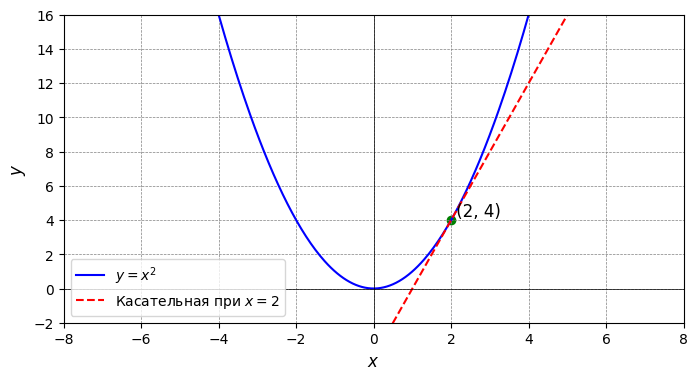

In [ ]:
#@title <b> Рисунок </b>
import matplotlib.pyplot as plt
import numpy as np

# Define the function and its derivative
def f(x):
    return x**2

def df(x):
    return 2*x

# Define the point of tangency
x_tangent = 2
y_tangent = f(x_tangent)
slope_tangent = df(x_tangent)

# Define the tangent line function based on the point of tangency and its slope
def tangent_line(x):
    return slope_tangent * (x - x_tangent) + y_tangent

# Generate x values for the plot
x_values = np.linspace(-8, 8, 400)
y_values = f(x_values)
tangent_values = tangent_line(x_values)

# Create the plot
plt.figure(figsize=(8, 4))
plt.plot(x_values, y_values, label='$y = x^2$', color='blue')
plt.plot(x_values, tangent_values, label=f'Касательная при $x = {x_tangent}$', color='red', linestyle='--')

# Highlight the tangency point
plt.scatter(x_tangent, y_tangent, color='green')
plt.text(x_tangent, y_tangent, f' ({x_tangent}, {y_tangent})', fontsize=12, verticalalignment='bottom')

# Set the limits for x and y axes
plt.xlim(-8, 8)
plt.ylim(-2, 16)

# Add labels and title
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$y$', fontsize=12)
#plt.title('График $y = x^2$ с касательной в точке $x = 2$', fontsize=14)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

Рисунок 1. "Крутизна" функции  в точке

"*Крутизной*" считается тангес угла наклона касательной к графику функции.
Касательную можно интуитивно воспринимать как прямую, которая "едва касается" графика в определенной точке. Для приблизительного определения касательной в интересующей нас точке $x$, можно нарисовать линию, пересекающую указанную точку $x$ и близкую к ней точку $x + \delta x$ ($\delta x \approx 0$).

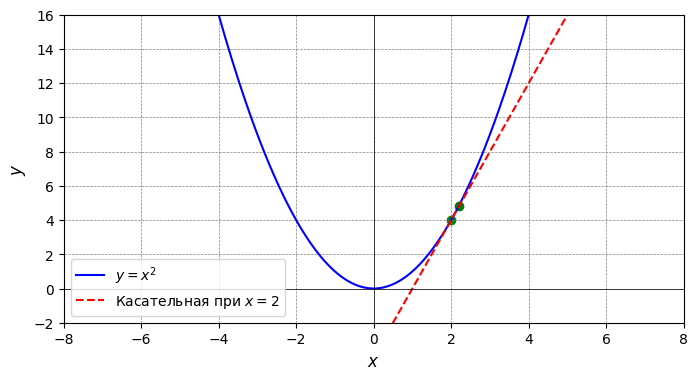

In [ ]:
#@title <b> Рисунок </b>
import matplotlib.pyplot as plt
import numpy as np

# Define the function and its derivative
def f(x):
    return x**2

def df(x):
    return 2*x

# Define the point of tangency
x_tangent = 2
y_tangent = f(x_tangent)
slope_tangent = df(x_tangent)

# Define the tangent line function based on the point of tangency and its slope
def tangent_line(x):
    return slope_tangent * (x - x_tangent) + y_tangent

# Generate x values for the plot
x_values = np.linspace(-8, 8, 400)
y_values = f(x_values)
tangent_values = tangent_line(x_values)

# Create the plot
plt.figure(figsize=(8, 4))
plt.plot(x_values, y_values, label='$y = x^2$', color='blue')
plt.plot(x_values, tangent_values, label=f'Касательная при $x = {x_tangent}$', color='red', linestyle='--')

# Highlight the tangency point
plt.scatter(x_tangent, y_tangent, color='green')
x_tangent += 0.2
y_tangent = x_tangent**2
plt.scatter(x_tangent, y_tangent, color='green')
#plt.text(x_tangent, y_tangent, f' ({x_tangent}, {y_tangent})', fontsize=12, verticalalignment='bottom')

# Set the limits for x and y axes
plt.xlim(-8, 8)
plt.ylim(-2, 16)

# Add labels and title
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$y$', fontsize=12)
#plt.title('График $y = x^2$ с касательной в точке $x = 2$', fontsize=14)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

Рисунок 2. Приблизительный метод расчета наклона графика функции

1. **Расчет крутизны касательной**:
   При точках $ x = 2.0 $ и $ x = 2.1 $ наклон касательной, вычисляемый как $ m = \frac{f(2.1) - f(2)}{2.1 - 2} = \frac{4.41 - 4}{0.1} = 4.1 $, приближённо равен крутизне функции в точке $ x = 2 $. При уменьшении шага до $ \delta x = 0.00001 $, тангенс угла наклона стремится к истинному значению производной $ m = 4 $.

2. **Предел для производной**:
   Производная $ f'(x) $ определяется как предел при $ \delta x \rightarrow 0 $, выраженный формулой
   $$ f'(x) = \lim_{\delta x \to 0} \frac{f(x + \delta x) - f(x)}{\delta x} $$ что отражает отношение малых приращений функции к приращениям аргумента.

<details>
  <summary>Текст</summary>

  Давайте проведем приблизительные численные расчеты наклона касательной. Для начала рассмотрим точку $x=2.0$ и близкую к ней точку $x=2.1$. Это значение будучи подставленные в функцию $f(x) = x 2$ дадут следующие значение зависимой переменной $f(2) = 4$, $f(2.1) = 4.41$. Как показано на *Рисунке 2*, тогда тангенс угла наклона будет равен:

  $$ m = \frac{y_2 - y_1}{x_2 - x_1} $$

  $$ m = \frac{f(x_2) - f(x_1)}{x_2 - x_1} $$

  $$ m = \frac{f(2.1) - f(2)}{2.1 - 2} $$

  $$ m = \frac{4.41 - 4}{0.1} = 4.1 $$

  Это приблизительно равно "крутизне" нашей функции в точке 2.

  Если еще уменьшить расстояние между точками к примеру, взять точки  $x = 2$ и соседнюю точку $x + \delta x = 2.00001$, значения функции в этих точках соответственно будет  $f(2) = 4$ и $f(2.00001) = 4.00004$, тогда тангенс угла наклона практически равен истинному значению 4. Следовательно, чем меньше величина шага $\delta x$, тем точнее мы приближаемся к значению производной в конкретной точке $x$ функции $f(x)$ . По сути производная и есть следующий предел:

  $$\frac{df(x)}{dx} = f {'}(x) = \lim_{\delta x \to 0} \frac{f(x+\delta x) - f(x)}{\delta x}$$

  Производная может обозначаться как $\frac{df(x)}{dx}$, что представляет отношение малых приращений функции (зависимой переменной) к приращениям аргумента (независимой переменной), или же дополнительным штрихом над символом функции $f {'}(x)$. Оба обозначения встречаются одинаково часто.

  В примере 1 приведен код на **Python**, который позволяет численно  рассчитывать производную функции. Просто по определению.
</details>

In [ ]:
# Пример 1. Численный расчет производной функции по определению
def derivative_x(f, x, step_size):
  m = (f(x + step_size) - f(x)) / ((x + step_size) - x)
  return m

def my_function(x):
  return x**2

slope_at_2 = derivative_x(my_function, 2, 0.1)
print(slope_at_2)
slope_at_2 = derivative_x(my_function, 2, 0.01)
print(slope_at_2)
slope_at_2 = derivative_x(my_function, 2, 0.001)
print(slope_at_2)
slope_at_2 = derivative_x(my_function, 2, 0.0001)
print(slope_at_2)
slope_at_2 = derivative_x(my_function, 2, 0.00001)
print(slope_at_2)

4.099999999999998
4.009999999999977
4.00100000000014
4.000099999999392
4.000010000000827


<details>
  <summary>Текст</summary>

  Ага, явно просматривается тенденция, что "крутизна" функции $f(x)$ в точке $x = 2$ приближается к значению 4 по мере стремления $\delta x$ к 0.

  Однако, производную можно вычислить не только численно, но и аналитически, если сама функция заданна в аналитическом виде ("выражается в виде формулы"). Давайте это сделаем для функции $f(x) = x^2$. По определению производная есть:

  $$
  f {'}(x) = \lim_{\delta x \to 0} \frac{f(x+\delta x) - f(x)}{\delta x}
  $$

  Явно выразим саму функцию $f(x) = x^2$ и раскроем квадрат суммы $(x + \delta x)^2$:

  $$ f {'}(x) = \lim_{\delta x \to 0} \frac{(x+\delta x) 2 - x 2}{\delta x} = \lim_{\delta x \to 0} \frac{x 2+2x \delta x + \delta x 2 - x 2}{\delta x} = \lim_{\delta x \to 0} \frac{2x \delta x + \delta x 2}{\delta x}  = \lim_{\delta x \to 0} (2x + \delta x)  $$

  Под пределом остается два слагаемых $2x$ зависит от предела, поэтому его можно вынести из-под функции предела, а предел  $\delta x$ очевидным образом равен нулю при стремлении $\delta x$ к нулю.

  $$ f {'}(x) = 2x + \lim_{\delta x \to 0} \delta x = 2x $$


  Можно доказать, что для функции вида $f(x) = x^n$ производная выражается как $f {'}(x) = n x^{n-1}$, где $n$ — это любое вещественное число. Существуют также правила для нахождения производных других аналитических функций, включая логарифмические и тригонометрические функции (см. Таблицу 1). Дополняя это правилами дифференцирования сумм и произведений, можно вывести производную почти для любой аналитической функции (см. Таблицу 2).
</details>

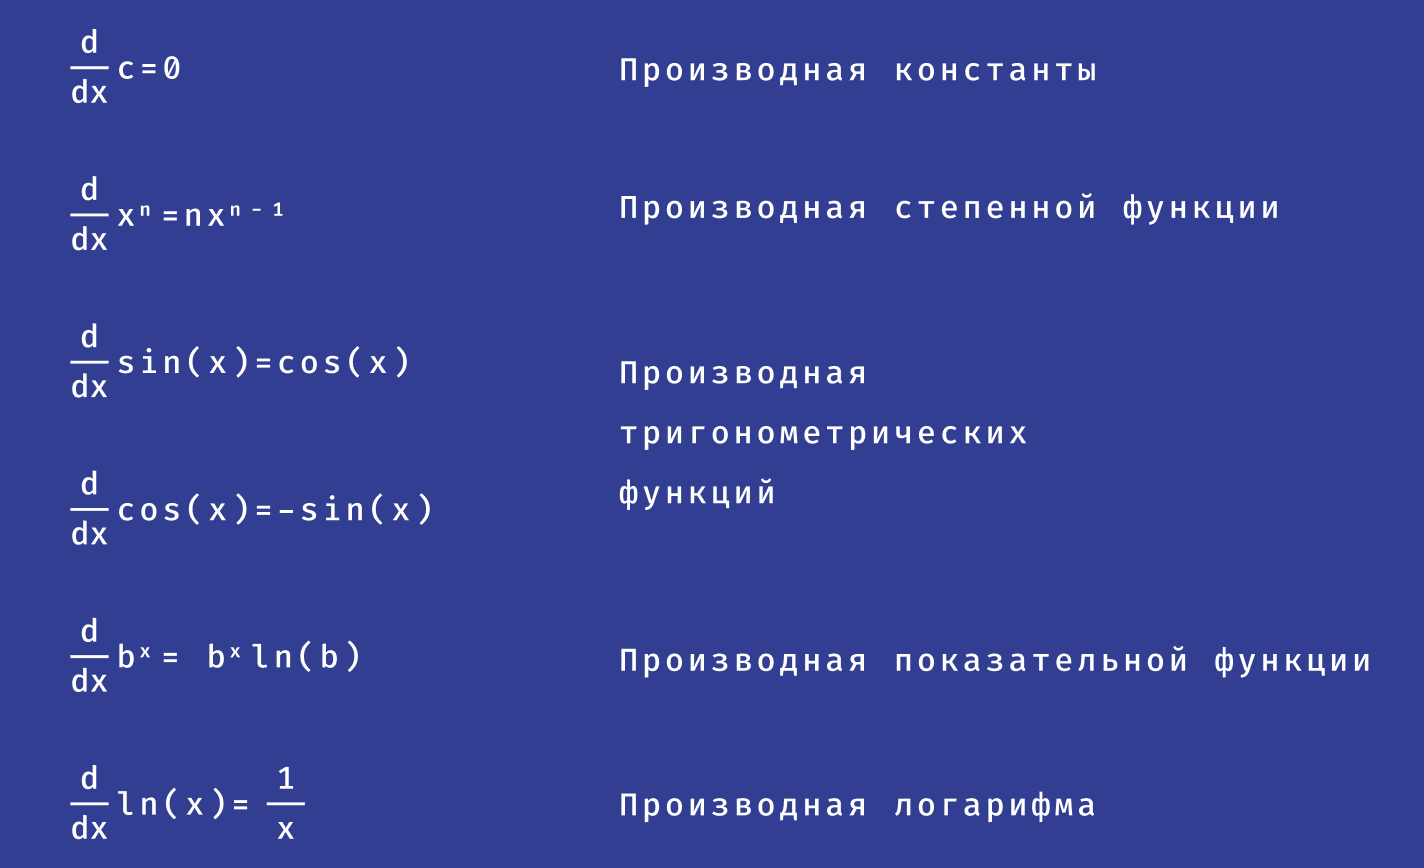

In [ ]:
#@title <b> Таблица </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1LHsyBMyTDyOPHADsIyi46nL0rmboIUMC/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=600))  # Adjust the width as needed

Taблица 1. Правила вычисления производный для элементарных аналитических функций

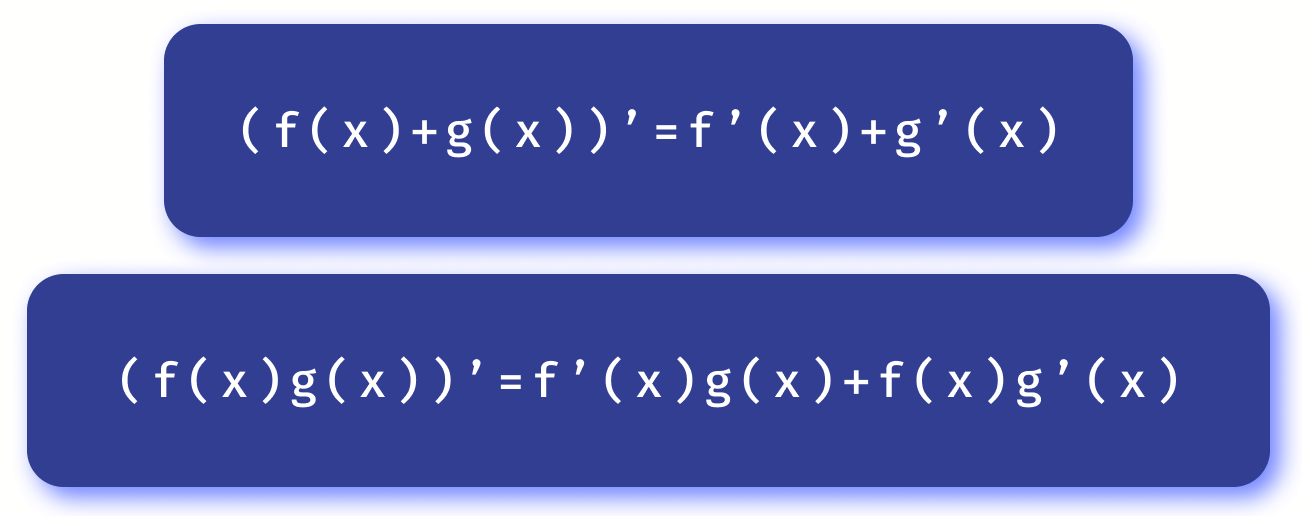

In [ ]:
#@title <b> Таблица </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/16Y7hlUDSlV2U2bOX8x_sVKfFNGx3kB8b/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=600))  # Adjust the width as needed


Таблица 2. Правила вычисления производной для суммы и произвдения функций .

<details>
  <summary>Текст</summary>

  Если вам не хочется вычислять производные с помощью ручки и бумаги. Есть отличные инструменты для символьного вычисления производных. Например, уже известный нам **SymPy**. *Пример 2* показывает как с помощью SymPy можно аналитически получить производную функции $f(x) = x^2$.
</details>


In [ ]:
# Пример  2. Расчет производных в SymPy
from sympy import *
# Инициализируем переменную 'x' для SymPy
x = symbols('x')
f = x**2
dx_f = diff(f)
print(dx_f)
# Расчет производной в конкретной точке x=2
print(dx_f.subs(x,2))

2*x
4


Давайте попробуем продифференцировать более сложную функцию, например, вот такую "кракозябру":

$$ f(x) = \frac{\sin(x)}{\ln(x)} + \frac{x^5}{x^{10} e^x + \ln(x)} $$


In [ ]:
# Пример  3. Расчет "сложной" производных в SymPy
import sympy as sp
# Шаг 1: Определяем символическую переменную
x = sp.symbols('x')
# Шаг 2: Определяем функцию
function = sp.sin(x) / sp.ln(x) + x**5 / (x**10 * sp.exp(x) + sp.ln(x))
# Шаг 3: Вычисляем производную
derivative = sp.diff(function, x)
# Шаг 4: Упростим производную (если необходимо) и выведем результат
simplified_derivative = sp.simplify(derivative)
print("Функция: f(x) =", function)
print("Производная: f'(x) =", simplified_derivative)

Функция: f(x) = x**5/(x**10*exp(x) + log(x)) + sin(x)/log(x)
Производная: f'(x) = -x**15*exp(x)/(x**10*exp(x) + log(x))**2 - 5*x**14*exp(x)/(x**10*exp(x) + log(x))**2 + 5*x**4*log(x)/(x**10*exp(x) + log(x))**2 - x**4/(x**10*exp(x) + log(x))**2 + cos(x)/log(x) - sin(x)/(x*log(x)**2)


<details>
  <summary>Текст</summary>

  `x = sp.symbols('x')` определяет `x` как символическую переменную для математических операций. Мы задаем функцию $f(x)$ с использованием выражений SymPy, таких как `sp.sin()`, `sp.ln()`, и `sp.exp()`. `sp.diff(function, x)` вычисляет производную функции по переменной $x$.  `sp.simplify(derivative)` используется для упрощения полученного выражения производной.
  
</details>

# Частные производные

Еще одной концепцией, с которой вы столкнётесь в машинном обучении являются частные производные. Это производные функций, которые имеют несколько входных переменных. Представьте себе это так. Вместо того чтобы находить наклон функции одной переменной, у нас есть наклоны по нескольким переменным в разных направлениях. Для каждой производной по данной переменной мы предполагаем, что другие переменные остаются постоянными. Взгляните на трехмерной-график функции
$$ f(x, y) = 2x^3 + 3y^3 $$
на *Рисунке 3*, и вы увидите, что у нас есть наклоны в двух направлениях для двух переменных.


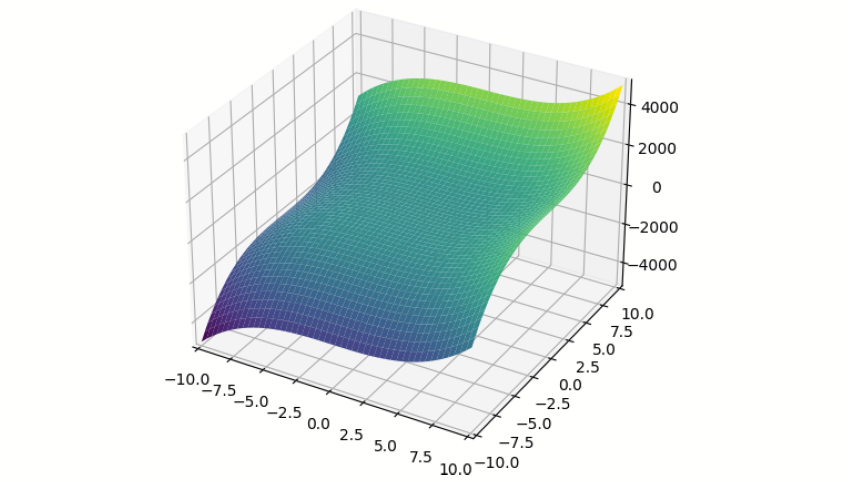

Рисунок 3. График функции $f(x, y) = 2x^3 + 3y^3$

<details>
  <summary>Текст</summary>

  Переменные $x$ и $y$ имеют свои собственные производные ${\partial }/{\partial x}$ и ${\partial}/{\partial y}$.

  Они представляют значения наклонов по отношению к каждой переменной на многомерной поверхности. Технически эти "наклоны" мы называем градиентами при работе с несколькими переменными.
  Имейте ввиду, что  символ частной производной ${\partial}$ немного отличается от символа производной функции одной переменной $d$. Ниже представлен пример вычисления производных по x и по y, а также код SymPy для вычисления этих производных:

</details>

6*x**2
9*y**2


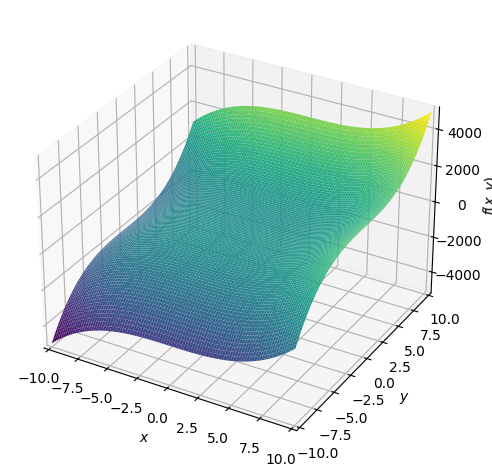

In [ ]:
# Пример 2. Вычисление частных производных
from sympy import *
import matplotlib.pyplot as plt
from sympy.plotting import plot3d
x,y = symbols('x y')
f = 2*x**3 + 3*y**3
dx_f = diff(f, x)

dy_f = diff(f, y)
print(dx_f)
print(dy_f)
plot3d(f)
plt.show()

Таким образом, для значений $(x, y)$ равных $(1, 2)$, наклон относительно $x$ равен $6 \times  1^2 = 6$, а наклон относительно $y$ равен $9 \times 2^2 = 36$.

# Дифференцирование сложной функции

Когда мы будем создавать нейронную сеть, нам понадобится специальный математический приём, называемый цепное правило или правило дифференцирования сложной функции. Для начала давайте изучим правило цепочки на простом алгебраическом примере. Допустим, вам даны две функции:

$y = x^2 + 1$

$z = y^3 - 2$

Мы видим, что функции $y(x)$ и $z(y)$ связаны, так как переменная $y$ это выходное значение первой функции и входное значение для второй функции. Это означает, что мы можем подставить первую функцию $y$ во вторую функцию $z$ и получить зависимость $z(x)$:

$z = (x^2 + 1)^3 - 2$

Итак, какова производная $z$ по отношению к $x$? У нас уже есть подстановка, выражающая $z$ через $x$. Давайте воспользуемся SymPy, чтобы вычислить это в *Примере 3*:



In [ ]:
# Пример 3. Вычисление частных производных
from sympy import *
z = (x**2 + 1)**3 - 2
dz_dx = diff(z, x)
print(dz_dx)
# 6*x*(x**2 + 1)**2

6*x*(x**2 + 1)**2


<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<details>
  <summary>Текст</summary>

  Таким образом:

  $$\frac{dz}{dx} = \frac{d}{dx}((x^2 + 1)^3 - 2) = 6 x (x^2 + 1)^2 $$

  Но можно и явно не выражать $z$ через $x$, тем более не всегда это удобно. Мы сначала вычислить производную $z$ по $y$:

  $$\frac{dz}{dy} = 3 y^2$$

  Затем вычислим производную $y$ по $x$:

  $$\frac{dy}{dx} = 2 x$$

  Пока просто умножим $\frac{dz}{dy}$ на $\frac{dy}{dx}$ получим:

  $$\frac{dz}{dy} \frac{dy}{dx} = 6 y^2 x$$

  Теперь вместо $y$ поставим явную зависимость от $x$:

  $$\frac{dz}{dy} \frac{dy}{dx} = 6 (x^2 + 1)^2 x$$

  Ого, это выражение в точности равно $\frac{dz}{dx}$. Таким образом, на частном примере мы продемонстрировали правило дифференцирования сложной фуннции:

  $$\frac{dz}{dx} = \frac{dz}{dy}\frac{dy}{dx}$$

  Это и есть цепное правило, которое утверждает, что для данной функции
  $y$ (с входной переменной
  $x$), "вложенной" в другую функцию $z$ (с входной переменной $y$), мы можем найти производную $z$ по отношению к
  $x$, умножив две производные $\frac{dz}{dy}$ и $\frac{dy}{dx}$ друг на друга.

  "Вложенность" часто может обозначаться как $z$($y$($x$)). Это выражение нам говорит, что $z$ зависит от $y$, которая зависит от $x$. Цепное правило достаточно просто обобщается и на "большую степень вложенности". Например, если $z(y(x(t(s))))$, то произвдноя $\frac{dz}{ds}$, будет вычисляться следующим образом:

  $$\frac{dz}{ds} = \frac{dz}{dy}\frac{dy}{dx}\frac{dx}{dt}\frac{dt}{ds}$$

  Заметьте, что этим операции умножения образуют "цепочку" умножений, где слагаемые "зацепляются" друг за друга, так как если смотреть слева-направо, то соседние слагаемые имеют одинаковую пару знаменатель-числитель:
</details>

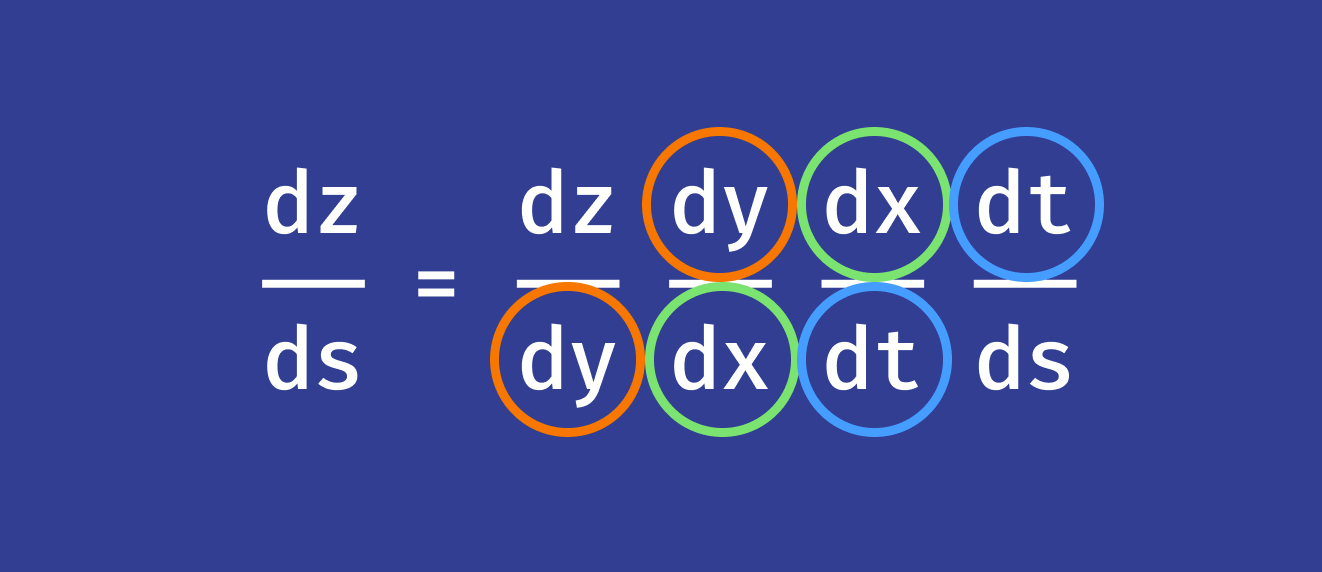

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1O--RjA2KntgCfPASyxmbgxuRF86AEEM-/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=600))  # Adjust the width as needed

<details>
  <summary>Текст</summary>

  Собсвенно поэтому это правило и называется цепным, чем больше "степень вложенности" переменных друг в друга, тем больше длинна такой цепочки.

  *Пример 4* показывает код на SymPy, который демонстрирует, что производная, полученная с помощью цепного правила, равна производной явно выраженной функций.

</details>

In [ ]:
# Пример 4
from sympy import *
x, y = symbols('x y')
# производная для первой функции
# необходимо использовать подчёркивание у y, чтобы избежать конфликта переменных
_y = x**2 + 1
dy_dx = diff(_y)
# производная для второй функции
z = y**3 - 2
dz_dy = diff(z)
# Вычисляем производную с помощью
# правила цепочки и без него, подставляя функцию y
dz_dx_chain = (dy_dx * dz_dy).subs(y, _y)
dz_dx_no_chain = diff(z.subs(y, _y))
# Подтверждаем правило цепочки, показывая, что оба результата равны
print(dz_dx_chain) # 6*x*(x**2 + 1)**2
print(dz_dx_no_chain) # 6*x*(x**2 + 1)**2

6*x*(x**2 + 1)**2
6*x*(x**2 + 1)**2


# Интегралы

Обратной операцией для взятия производной является операция интегрирования, которая позволяет находить площадь под кривой в заданных пределах. В лекциях, посвященных теории вероятности и статистике, мы будем находить площади под распределениями вероятностей.

Давайте подойдем к изучению интегралов интуитивно, используя метод, называемый суммами Римана, который адаптируется к любой непрерывной функции. Во-первых, обратим внимание, что нахождение площади под прямой линей a.k.a линейная функция достаточно простая задача. Рассмотрим  функцию $f(x) = 2 x$, и мы хотим найти площадь под линией между 0 и 1, как показано на *Рисунке 4*:


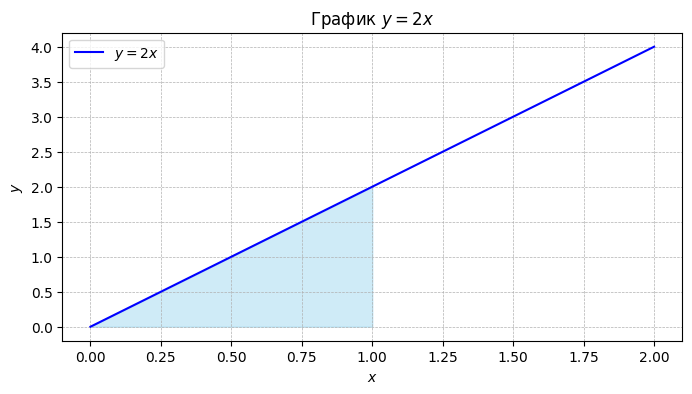

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt

# Определим функцию y = 2x
def f(x):
    return 2 * x

# Генерируем значения x
x = np.linspace(0, 2, 400)
y = f(x)

# Создаем график
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$y = 2x$', color='blue')

# Закрасим область под графиком от x = 0 до x = 1
x_fill = np.linspace(0, 1, 400)
y_fill = f(x_fill)
plt.fill_between(x_fill, y_fill, color='skyblue', alpha=0.4)

# Добавим подписи осей и заголовок
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('График $y = 2x$')

# Добавим сетку
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Добавим легенду
plt.legend()

# Показать график
plt.show()

Рисунок 4. Расчет площади под линейной функцией

Мы находим площадь, ограниченную между линией $f(x)$ и осью  $x$ в диапазоне $x$ от $0.0$ до $1.0$. Если вспомнить формулы из школьной геометрии, то площадь $(A)$ треугольника равна $A = \frac{1}{2} b h $, где $b$ — длина основания, $h$ — высота. Мы можем по рисунку определить, что $b = 1$ и $h = 2$. Подставляем значения в формулу для площади получаем $1$:

$$
A = \frac{1}{2} b h
$$

$$
A = \frac{1}{2} \times 1 \times 2
$$

$$
A = 1
$$

Это было просто, правда? Но давайте рассмотрим функцию, для которой трудно найти площадь под функцией $f(x) = x^2 + 1$. Какова же её площадь между точками 0 и 1 (*Рисунок 5*)?

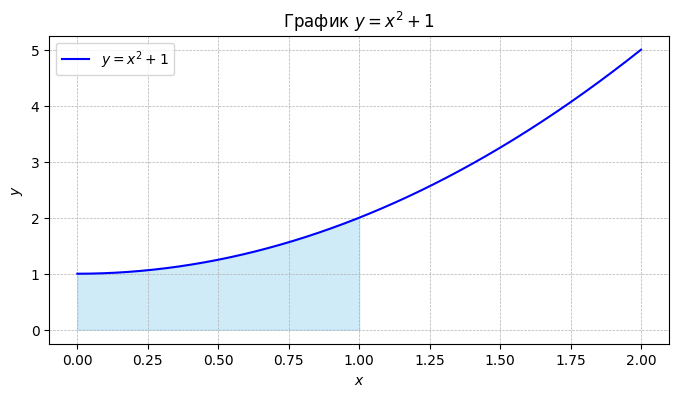

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 1

# Генерируем значения x
x = np.linspace(0, 2, 400)
y = f(x)

# Создаем график
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$y = x^2 + 1$', color='blue')

# Закрасим область под графиком от x = 0 до x = 1
x_fill = np.linspace(0, 1, 400)
y_fill = f(x_fill)
plt.fill_between(x_fill, y_fill, color='skyblue', alpha=0.4)

# Добавим подписи осей и заголовок
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('График $y = x^2 + 1$')

# Добавим сетку
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Добавим легенду
plt.legend()

# Показать график
plt.show()

Рисунок 5. Вычисление площади под нелинейными функциями не так очевидно

<details>
  <summary>Текст</summary>
  
  Мы хотим вычислить площадь под кривой $f(x)$ и над осью x диапазоне от  $0$ до $1$. "Кривая" линия не даёт нам простой геометрической формулы для нахождения площади, но вот трюк с бесконечностями, который мы можем использовать.

  Что, если мы разместим под кривой пять прямоугольников одинаковой длины, как показано на Рисунке 6, где высота каждого из них будет простираться от оси
  $x$ до точки, где "середина" прямоугольника пересекает кривую $f(x)$.

  Площадь одного прямоугольника равна $А = длина \times ширина$, поэтому мы могли бы легко сложить площади всех прямоугольников, чтобы получить оценку истинной площади под кривой $f(x)$.

  Кажется, что это достаточно грубое приближение? А что, если мы разместим 100 прямоугольников? 1000? 100000? По мере увеличения числа прямоугольников и уменьшения их ширины, не приближается ли наша оценка к истинной площади под кривой? Да, это именно так, и это ещё один случай в математическом анализе, когда мы что-то увеличиваем до бесконечности или уменьшаем до нуля, чтобы приблизиться к истинному значению.
</details>

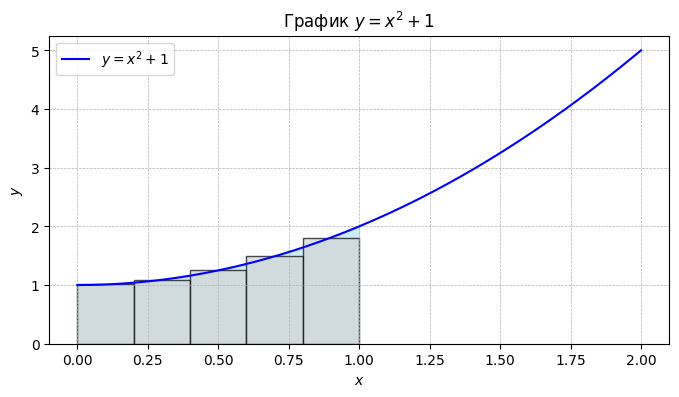

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt

# Определим функцию y = x^2 + 1
def f(x):
    return x**2 + 1

# Генерируем значения x
x = np.linspace(0, 2, 400)
y = f(x)

# Создаем график
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$y = x^2 + 1$', color='blue')

# Закрасим область под графиком от x = 0 до x = 1
x_fill = np.linspace(0, 1, 400)
y_fill = f(x_fill)
plt.fill_between(x_fill, y_fill, color='skyblue', alpha=0.4)

# Добавим подписи осей и заголовок
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('График $y = x^2 + 1$')

# Параметры прямоугольников
a = 0
b = 1
n = 5  # количество прямоугольников

# Ширина одного прямоугольника
width = (b - a) / n

# Визуализация прямоугольников
for i in range(n):
    mid_point = a + i * width + width / 2
    height = f(mid_point)
    plt.bar(mid_point, height, width=width, align='center', edgecolor='black', color='lightgrey', alpha=0.7)

# Добавим сетку
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Добавим легенду
plt.legend()

# Показать график
plt.show()

Рисунок 6. Размещение прямоугольников под кривой для приближённого нахождения площади

<details>
  <summary>Текст</summary>
  
  Давайте попробуем реализовать такое приближение интеграла на Python. Во-первых, нам нужна функция, которая приближённо вычисляет интеграл, и мы назовём её `approximate_integral()`. Аргументы `a` и `b` будут задавать интервал интегрирования для $x$, соответственно. `n` задаёт количество прямоугольников, которыми мы будем аппроксимировать интеграл, а `f` будет функцией, которую мы интегрируем. Мы реализуем эту функцию в *Примере 5*, а затем используем её для интегрирования  функции $ f(x) = x^2 + 1 $ с пятью прямоугольниками в диапазоне от 0.0 до 1.0.

</details>

In [ ]:
# Пример 5: Функция для приближенного вычисления интеграла методом прямоугольников
def approximate_integral(a, b, n, f):
    # Вычисляем ширину каждого прямоугольника
    delta_x = (b - a) / n

    # Инициализируем суммарную площадь
    total_sum = 0

    # Проходим по каждому прямоугольнику
    for i in range(1, n + 1):
        # Вычисляем середину текущего прямоугольника
        midpoint = 0.5 * (2 * a + delta_x * (2 * i - 1))

        # Прибавляем значение функции в середине прямоугольника к суммарной площади
        total_sum += f(midpoint)

    # Возвращаем приблизительную площадь под кривой
    return total_sum * delta_x

# Определяем функцию y = x^2 + 1
def my_function(x):
    return x**2 + 1

# Вычисляем площадь под кривой на интервале от 0 до 1 с 5 прямоугольниками
area = approximate_integral(a=0, b=1, n=5, f=my_function)

# Печатаем результат
print(area)

1.33


Итак, мы получили площадь 1.33. Что произойдёт, если мы используем 1000 прямоугольников? А что если 1000000? Давайте рассмотрим это в *Примере 6*.



In [ ]:
# Пример 6
area = approximate_integral(a=0, b=1, n=1000, f=my_function)
print(area)

area = approximate_integral(a=0, b=1, n=1000000, f=my_function)
print(area)

1.333333250000001
1.3333333333332733


Хорошо, что здесь мы приближаемся к значению 1.333, где часть ".333" бесконечно повторяется. Если бы это было рациональное число, скорее всего, оно было бы равно $\frac{4}{3}$. По мере увеличения числа прямоугольников приближение начинает достигать своего предела.

Теперь, когда у нас есть некоторое представление о том, чего мы пытаемся достичь и почему. Давайте попробуем вычислить этот интеграл с помощью SymPy:

In [ ]:
# Пример 7
from sympy import *
# Объявляем 'x' для SymPy
x = symbols('x')
# Теперь просто используем синтаксис Python для определения функции
f = x**2 + 1
# Вычисляем интеграл функции по переменной x
# для площади между x = 0 и 1
area = integrate(f, (x, 0, 1))
print(area) # выводит 4/3

4/3



Круто! Итак, площадь действительно равна $\frac{4}{3}$, как мы и показали с помощью нашего предыдущего метода приближенного метода. Стоит отметить, обычный Python (и многие другие языки программирования) поддерживают только десятичные дроби, но системы символьной алгебры, такие как SymPy, дают нам точные рациональные числа.

# Что такое градиентный спуск?

**Градиентный спуск** — это оптимизационный алгоритм, часто используемый для минимизации функции в общем случае. Это основной алгоритм для минимизации функции потерь в задачах машинного обучения. Он помогает найти минимальное значение функции, что соответствует для задач машинного обучения нахождению наиболее точных параметров модели.

Кстати, под оптимизацией обычно подразумевают поиск минимума функции. Минимумы функции могут локальными и глобальными. Локальный минимум функции — это точка, в которой значение функции меньше, чем в близлежащих точках, но, возможно, больше, чем в отдалённых точках. Глобальный минимум — это точка, в которой значение функции меньше, чем во всех других допустимых точках. Разница между глобальным и локальными минимумами показана на *Рисунке 7*:

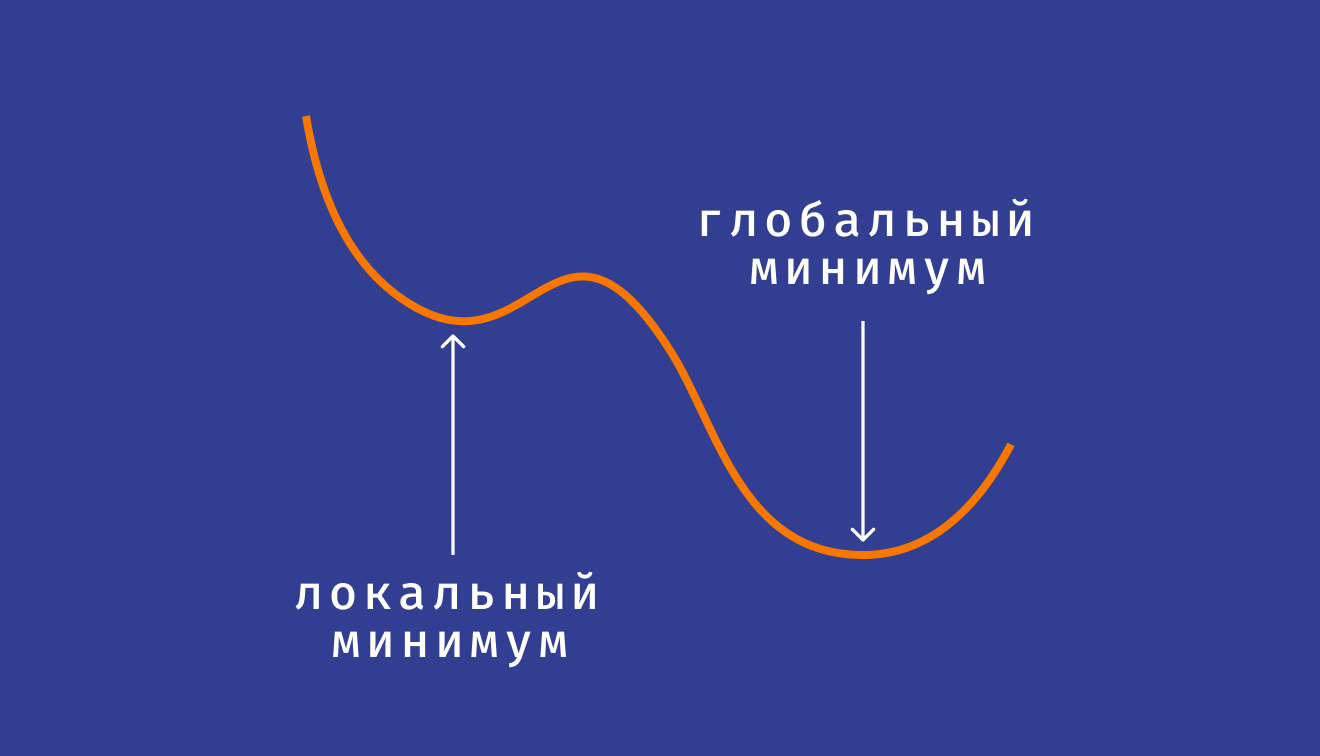

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1Dkj8j70-1dz8NxwBYL6rmD_dVYH-fhFv/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=500))  # Adjust the width as needed

Рисунок 7. Разница между глобальным и локальным минимумом.

<details>
  <summary>Текст</summary>
  
  Градиентный спуск ищет локальный минимум функции. Как он это делает? Для этого ему нужно всего два числа, если мы говорим о функции одной переменной: значение функции в текущей точке и её производная в этой точке.

  Производная показывает "крутизну" функции, указывая направление наибольшего изменения. Зная её, мы "идём" в сторону уменьшения этой крутизны, так как в этом направлении значение функции будет уменьшаться. Это похоже на спуск с горы: вы постоянно идёте вниз, и с каждым шагом ваша высота уменьшается относительно уровня моря уменьшается.

  Давайте формализуем основные шаги градиентного спуска:

  *   Инициализация: Начнем с некоторых начальных значений аргумента $x_0$.
  *   Вычисление градиента: определяем направление, в котором увеличивается значение функции.
  *   Обновление параметров: двигаемся в противоположном направлении градиента (вниз по градиенту) на некоторый шаг (шаг обучения $\alpha$).
  *   Повторение: Повторяем процесс до тех пор, пока не достигнем минимума функции, либо обновления параметров не станут пренебрежимо малыми.
</details>

Теперь давайте реализуем этот процесс на Python. Мы будем минимизировать простую функцию $f(x) = x^2$


Итерация 1: x = -6.0, f(x) = 36.0
Итерация 2: x = 3.6000000000000014, f(x) = 12.96000000000001
Итерация 3: x = -2.160000000000001, f(x) = 4.665600000000005
Итерация 4: x = 1.2960000000000007, f(x) = 1.6796160000000018
Итерация 5: x = -0.7776000000000005, f(x) = 0.6046617600000008
Итерация 6: x = 0.4665600000000003, f(x) = 0.2176782336000003
Итерация 7: x = -0.2799360000000002, f(x) = 0.0783641640960001
Итерация 8: x = 0.16796160000000016, f(x) = 0.028211099074560052
Итерация 9: x = -0.10077696000000008, f(x) = 0.010155995666841616
Итерация 10: x = 0.060466176000000066, f(x) = 0.003656158440062984
Итерация 11: x = -0.036279705600000045, f(x) = 0.0013162170384226747
Итерация 12: x = 0.02176782336000003, f(x) = 0.00047383813383216293
Итерация 13: x = -0.013060694016000018, f(x) = 0.0001705817281795787
Итерация 14: x = 0.007836416409600012, f(x) = 6.140942214464835e-05
Итерация 15: x = -0.004701849845760008, f(x) = 2.210739197207341e-05
Итерация 16: x = 0.002821109907456005, f(x) = 7.95866

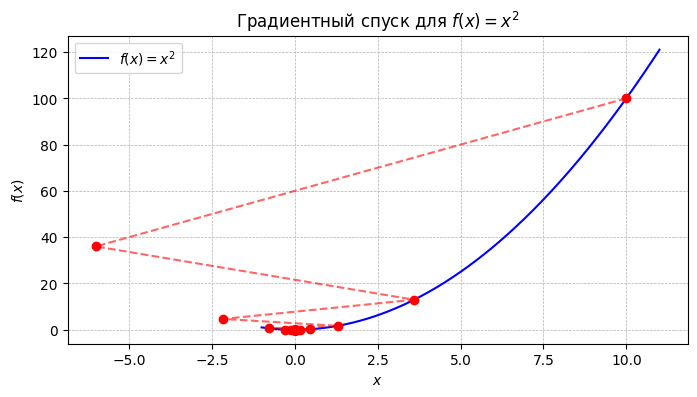

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Функция f(x) = x^2
def f(x):
    return x**2

# Производная функции f(x) = 2x
def gradient_f(x):
    return 2 * x

# Реализация градиентного спуска
def gradient_descent(starting_point, learning_rate, iterations):
    x = starting_point  # Инициализация начальной точки
    points = [x]  # Список для хранения всех точек
    for i in range(iterations):
        grad = gradient_f(x)  # Вычисление градиента в текущей точке
        x = x - learning_rate * grad  # Обновление параметра x по градиенту
        points.append(x)  # Добавляем новую точку в список
        print(f"Итерация {i+1}: x = {x}, f(x) = {f(x)}")  # Печатаем текущую итерацию, значение x и значение функции f(x)
    return x, points  # Возвращаем точку минимума и список всех точек

# Начальное значение x
starting_point = 10
# Шаг обучения
learning_rate = 0.8
# Количество итераций
iterations = 100

# Запуск градиентного спуска
minimum, points = gradient_descent(starting_point, learning_rate, iterations)
print(f"Минимальное значение x: {minimum}")

# Визуализация процесса градиентного спуска
x_values = np.linspace(-1, 11, 400)  # Генерация x-значений для графика функции
y_values = f(x_values)  # Вычисление значений функции f(x)

plt.figure(figsize=(8, 4))
plt.plot(x_values, y_values, label='$f(x) = x^2$', color='blue')  # Построение графика функции
plt.scatter(points, f(np.array(points)), color='red', zorder=5)  # Отображение точек, достигнутых в процессе градиентного спуска
plt.plot(points, f(np.array(points)), linestyle='--', color='red', alpha=0.6, zorder=5)  # Соединение точек линиями

# Подписи осей и заголовок
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Градиентный спуск для $f(x) = x^2$')

# Добавим сетку и легенду
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

# Отображение графика
plt.show()

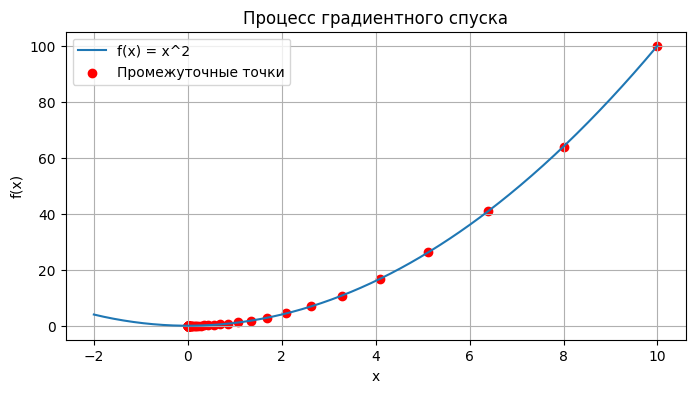

In [ ]:
# Иллюстрация процесса градиентного спуска
x_values = np.linspace(-2, 10, 400)
y_values = f(x_values)

plt.figure(figsize=(8, 4))
plt.plot(x_values, y_values, label='f(x) = x^2')
plt.scatter(points, f(np.array(points)), color='red', label='Промежуточные точки')
plt.title('Процесс градиентного спуска')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()